In [1]:
from functions import *
import matplotlib.pyplot as plt
def get_QLF(z, bin_num, dM, obscured, Mmid = 10., smhm_scat = .3, prob_zero = [0,0,0], standev = [.85, .85, .35]):

    qlf = QLF(z, bin_num)
    qlf.get_dNdMstar(smhm_scat)
    qlf.get_SMBM(dM, Mmid)
    qlf.get_dNdMbh()
    qlf.get_dNdL(prob_zero, standev, obscured)
    
    return qlf.LumBins, qlf.dNdL


In [5]:
%prun get_QLF(2,100,.6,.7, Mmid=10.7,standev = [.85,.85,.3])


         4593 function calls (4588 primitive calls) in 0.046 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      101    0.007    0.000    0.007    0.000 functions.py:95(get_Mstar)
        3    0.004    0.001    0.004    0.001 fromnumeric.py:2847(ndim)
        5    0.003    0.001    0.023    0.005 shape_base.py:270(apply_along_axis)
      100    0.002    0.000    0.002    0.000 functions.py:131(gauss_array)
      100    0.002    0.000    0.004    0.000 functions.py:189(get_mean_etas)
       10    0.002    0.000    0.002    0.000 fromnumeric.py:592(transpose)
        1    0.002    0.002    0.002    0.002 necompiler.py:765(evaluate)
       10    0.002    0.000    0.002    0.000 {method 'reshape' of 'numpy.ndarray' objects}
        2    0.002    0.001    0.006    0.003 cosmology.py:2140(sigma)
        3    0.001    0.000    0.001    0.000 {built-in method scipy.interpolate._fitpack._spl_}
        2    0.001    0.001    0.001 

Text(0,0.5,'$\\log \\Phi (Mpc^{-3} mag^{-1})$')

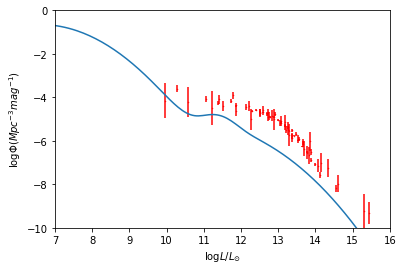

In [2]:
xi, yi = get_QLF(6.,200,.3,.6, Mmid=10.,standev = [.85,.85,.3])
plt.plot(xi, yi)
z = 2
x, y , yerr = grab_obs(z)
plt.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .5,color='r')
plt.axis([7,16,-10,0])
plt.xlabel(r'$\log L/L_{\odot}$')
plt.ylabel(r'$\log \Phi (Mpc^{-3} mag^{-1})$')


MCMC stuff.

In [3]:
import emcee
import corner
import scipy.optimize as op
from functions import *
import matplotlib.pyplot as plt

In [8]:
def model_func(x, p):
    p1, p2 = p
    xm, ym = get_QLF_mcmc(p1, p2)
    y = np.interp(x, xm, ym)
    return y

def lnchi2(p, x, y, err): #lnlike
    
    chi2 = -0.5*np.sum((y-model_func(x,p))**2/(err**2))
    return chi2

def lnprior(p):
    p1, p2 = p
    if 0. < p1 < 3. and 0. < p2 < 1.:
        return 0.0
    return -np.inf

def lnprob(p, x, y, err):
    lp = lnprior(p)
    if np.isfinite(lp):
        return lp + lnchi2(p, x, y, err)
    return -np.inf

z = 5.
bin_num = 200
smhm_scat = .3

qlf = QLF(z, bin_num)
qlf.get_zparams()
qlf.get_dNdMstar(smhm_scat)

### if we go through mcmc for one z value without changing the bin_num of smhm scatter we can do this
def get_QLF_mcmc(dM, obscured, Mmid = 10., prob_zero = [0,0,0], standev = [.85, .85, .35]):

    qlf.get_SMBM(dM, Mmid)
    qlf.get_dNdMbh()
    qlf.get_dNdL(prob_zero, standev, obscured)
    
    return qlf.LumBins, qlf.dNdL



In [9]:
xt, yt , yerr = np.array(grab_obs(z))
p = [.5,.5]
ndim, nwalkers = 2, 20

nll = lambda *args: -lnchi2(*args)
result = op.minimize(nll, p, args=(xt, yt, yerr),method = 'Nelder-Mead')

pos = [result["x"] + 1e-4*np.random.randn(ndim) for i in range(nwalkers)]
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(xt,yt,yerr))
sampler.run_mcmc(pos,300)

print(result)


 final_simplex: (array([[0.4263151 , 0.75059816],
       [0.4263117 , 0.75066361],
       [0.4263109 , 0.75063513]]), array([3.45637776, 3.45639576, 3.45640205]))
           fun: 3.45637775858106
       message: 'Optimization terminated successfully.'
          nfev: 130
           nit: 64
        status: 0
       success: True
             x: array([0.4263151 , 0.75059816])


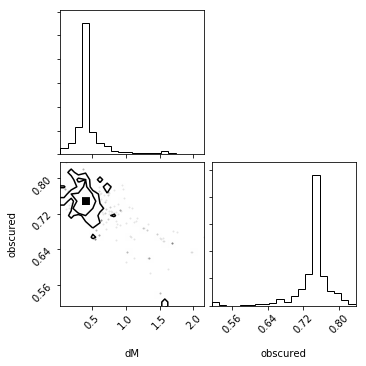

In [10]:
samples = sampler.chain[:,:50,:].reshape((-1, ndim))
fig = corner.corner(samples, labels = ['dM','obscured'])
mcmcdM, mcmcObs = np.mean(samples[:,0]), np.mean(samples[:,1])


Text(0,0.5,'$\\log \\Phi (Mpc^{-3} mag^{-1})$')

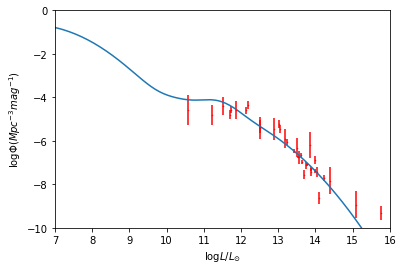

In [7]:
xi, yi = get_QLF_mcmc(mcmcdM, mcmcObs)
plt.plot(xi, yi)
plt.errorbar(xt, yt, yerr = yerr, fmt = 'o', markersize = .5,color='r')
plt.axis([7,16,-10,0])
plt.xlabel(r'$\log L/L_{\odot}$')
plt.ylabel(r'$\log \Phi (Mpc^{-3} mag^{-1})$')

Stuff I did to fix the interp issue.

13.000000000000007
11.243362186272641 13.000000000000007
12.900000000000007


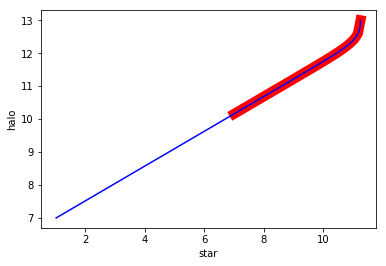

In [13]:
z = 5.
bin_num = 20
Lum = [5,16]
Stell = [7,12]

qlf = QLF(z, bin_num)


max_halo = 15
mhalo = np.linspace(7,max_halo,50)
mstar_h = qlf.get_Mstar(mhalo)

plt.xlabel('star')
plt.ylabel('halo')
stop = np.argmin(sorted(mstar_h) == mstar_h)
while stop != 0:
    max_halo -= .1
    mhalo = np.linspace(7,max_halo,50)
    mstar_h = qlf.get_Mstar(mhalo)
    stop = np.argmin(sorted(mstar_h) == mstar_h)
    
    
max_stell = qlf.get_Mstar(max_halo)
mstar = np.linspace(7,max_stell,50)
mhalo_s = np.interp(mstar, mstar_h, mhalo)
    
plt.plot(mstar, mhalo_s, c='r',linewidth=10)
plt.plot(mstar_h, mhalo, c = 'b')
print(max_stell, max_halo)

slopes = qlf.get_slope(mhalo)
while slopes[-1] < 0:
    max_halo -= .1
    mhalo = np.linspace(7,max_halo,50)
    slopes = qlf.get_slope(mhalo)
print(max_halo)